# Entangler Core Timing Report

This notebook summarizes timing measurements comparing the ARTIQ CPU TTL timestamp branch with the entangler core for the current local loopback setup.

Confirmed loopbacks:

```text
ttl5 output -> ttl1 input    entangler output 1 -> entangler input 1
ttl4 output -> ttl3 input    entangler output 0 -> entangler input 3
```

Runtime settings must match the flashed bitstream:

```toml
NUM_PATTERNS_ALLOWED = 2
```

With four entangler inputs, this makes the pattern enable shift equal to `8`.

## Summary Conclusion

For the current no-master/satellite workflow, replacing the CPU timestamp branch with the current entangler core is not recommended if the goal is a faster Python-visible response.

The entangler core can produce a faster hardware success event when the cycle is tight. The new narrow-window test succeeded at both `~200 ns` and `40 ns` post-click hardware done windows, and the `40 ns` window was faster. However, if Python must wait for `run_mu()` and then execute the microwave/FORT/readout branch, the return-to-Python overhead is still slower than the simple CPU timestamp branch in the tested local scenarios.

A real speedup would require moving the time-critical response into gateware, such as `pattern match -> hardware TTL response` or `pattern match -> gateware response sequencer`.

## Narrow 200 ns And 40 ns Window Test

A follow-up hardware loopback test narrowed the output pulse and input gate, then pulled the cycle endpoint closer to the observed click. Both runs used `pulse_offset_us=1.0`, `pulse_width_us=0.04`, `cpu_gate_width_us=10.0`, `entangler_gate_pre_us=0.10`, `entangler_gate_post_us=0.06`, and `20` repetitions.

| Target done window | Cycle length | Successes | CPU decision | Hardware done | `run_mu()` return | Done - CPU | Return - CPU |
|---|---:|---:|---:|---:|---:|---:|---:|
| `~200 ns` | `1.276 us` | `20 / 20` | `1077 mu` | `207 mu` | `1387 mu` | `-869 mu` | `+310 mu` |
| `40 ns` | `1.104 us` | `20 / 20` | `1070 mu` | `40 mu` | `1210 mu` | `-1030 mu` | `+140 mu` |

The `40 ns` window is faster. It moved the hardware success event about `167 ns` earlier than the `~200 ns` case and reduced the Python-visible `run_mu()` return time. The return to Python was still slower than the direct CPU timestamp branch because the RTIO/driver handoff remains in the path.

The matching gateware simulation also succeeded for literal `200 ns` and `40 ns` cycle lengths; the `40 ns` simulated cycle reached `done_stb` first. The stock entangler-core simulation tests passed with `3 passed`, aside from the existing unknown `slow` pytest mark warning.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

MU_TO_US = 1e-3  # ref_period is 1 ns, so 1000 mu = 1 us

conditions = [
    {
        "name": "baseline",
        "shots": 25,
        "cpu_decision_mu": 1061,
        "entangler_done_mu": 4928,
        "entangler_return_mu": 6087,
        "done_minus_cpu_mu": 3866,
        "return_minus_cpu_mu": 5026,
        "pulse_offset_us": 2.0,
        "pulse_width_us": 2.0,
        "cycle_us": 7.0,
    },
    {
        "name": "tight_entangler_cycle",
        "shots": 25,
        "cpu_decision_mu": 1054,
        "entangler_done_mu": 528,
        "entangler_return_mu": 1694,
        "done_minus_cpu_mu": -526,
        "return_minus_cpu_mu": 639,
        "pulse_offset_us": 1.0,
        "pulse_width_us": 0.2,
        "cycle_us": 1.6,
    },
    {
        "name": "fast_hardware_done",
        "shots": 25,
        "cpu_decision_mu": 1065,
        "entangler_done_mu": 247,
        "entangler_return_mu": 1439,
        "done_minus_cpu_mu": -817,
        "return_minus_cpu_mu": 373,
        "pulse_offset_us": 1.0,
        "pulse_width_us": 0.2,
        "cycle_us": 1.32,
    },
    {
        "name": "early_click_custom",
        "shots": 20,
        "cpu_decision_mu": 1062,
        "entangler_done_mu": 423,
        "entangler_return_mu": 1600,
        "done_minus_cpu_mu": -638,
        "return_minus_cpu_mu": 538,
        "pulse_offset_us": 0.5,
        "pulse_width_us": 0.1,
        "cycle_us": 1.0,
    },
]

for row in conditions:
    print(
        f"{row['name']:24s} | CPU {row['cpu_decision_mu']:5d} mu | "
        f"done {row['entangler_done_mu']:5d} mu | return {row['entangler_return_mu']:5d} mu | "
        f"done-CPU {row['done_minus_cpu_mu']:6d} mu | return-CPU {row['return_minus_cpu_mu']:6d} mu"
    )

baseline                 | CPU  1061 mu | done  4928 mu | return  6087 mu | done-CPU   3866 mu | return-CPU   5026 mu
tight_entangler_cycle    | CPU  1054 mu | done   528 mu | return  1694 mu | done-CPU   -526 mu | return-CPU    639 mu
fast_hardware_done       | CPU  1065 mu | done   247 mu | return  1439 mu | done-CPU   -817 mu | return-CPU    373 mu
early_click_custom       | CPU  1062 mu | done   423 mu | return  1600 mu | done-CPU   -638 mu | return-CPU    538 mu


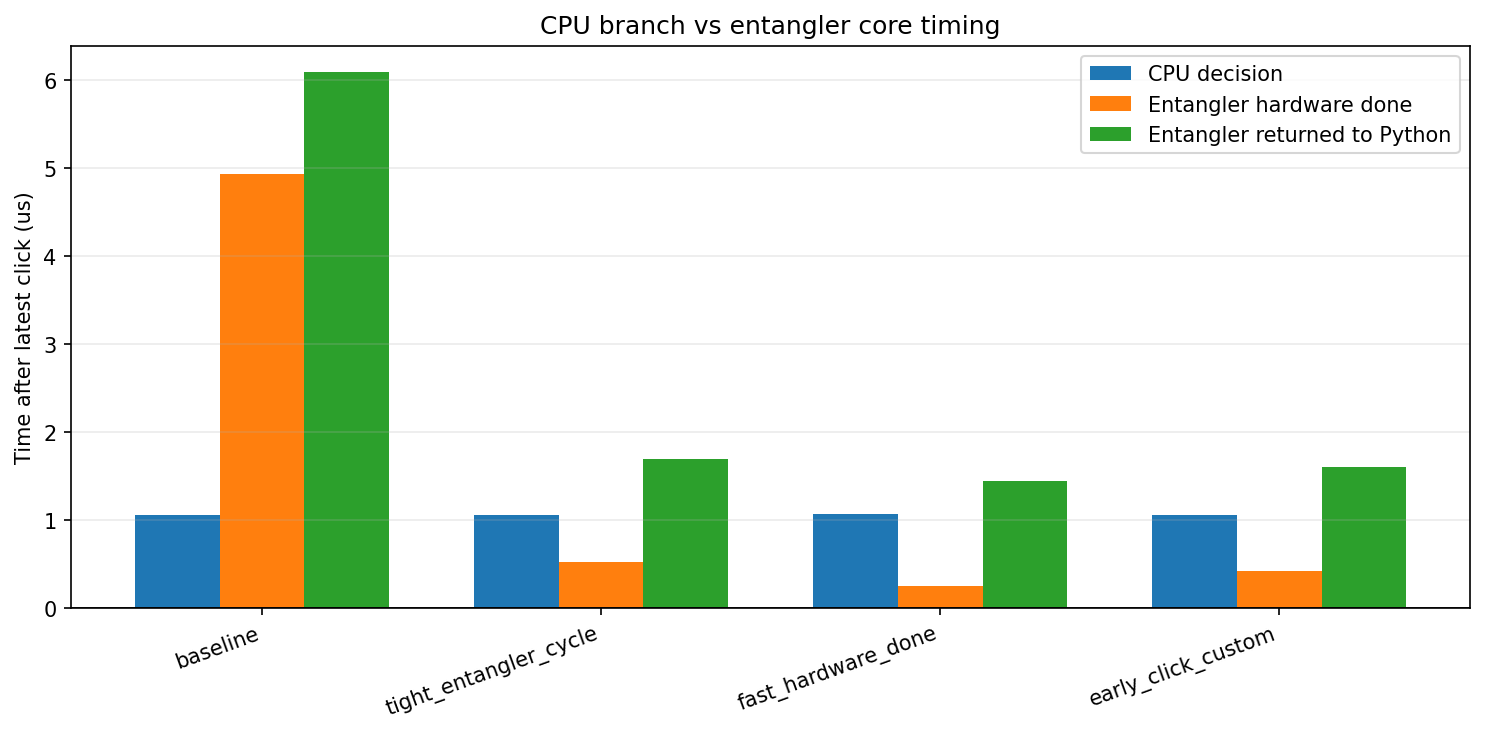

In [19]:
names = [row["name"] for row in conditions]
x = np.arange(len(names))
cpu = np.array([row["cpu_decision_mu"] for row in conditions]) * MU_TO_US
done = np.array([row["entangler_done_mu"] for row in conditions]) * MU_TO_US
ret = np.array([row["entangler_return_mu"] for row in conditions]) * MU_TO_US

width = 0.25
fig, ax = plt.subplots(figsize=(10, 5),dpi=150)
ax.bar(x - width, cpu, width, label="CPU decision")
ax.bar(x, done, width, label="Entangler hardware done")
ax.bar(x + width, ret, width, label="Entangler returned to Python")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Time after latest click (us)")
ax.set_title("CPU branch vs entangler core timing")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

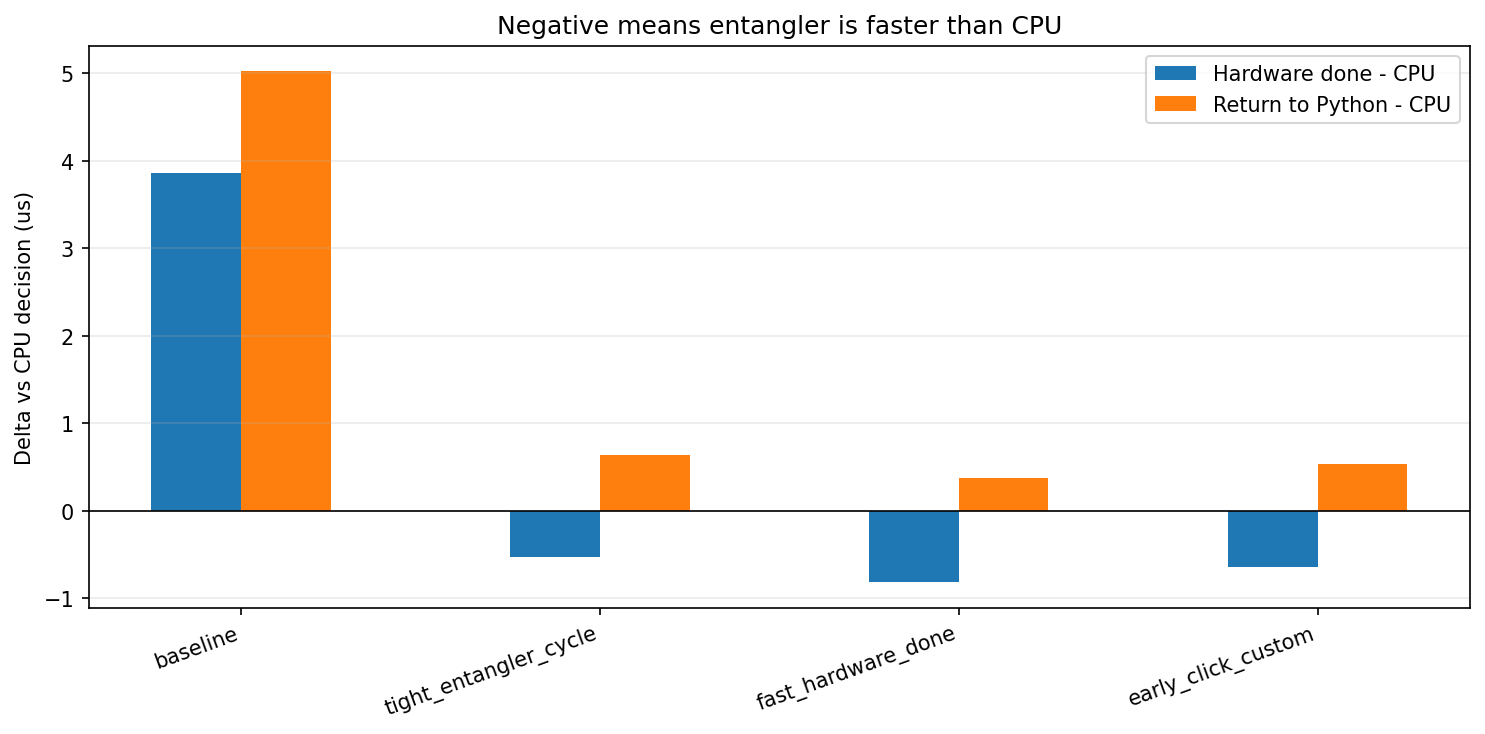

In [18]:
done_delta = np.array([row["done_minus_cpu_mu"] for row in conditions]) * MU_TO_US
return_delta = np.array([row["return_minus_cpu_mu"] for row in conditions]) * MU_TO_US

fig, ax = plt.subplots(figsize=(10, 5), dpi = 150)
ax.bar(x - width / 2, done_delta, width, label="Hardware done - CPU")
ax.bar(x + width / 2, return_delta, width, label="Return to Python - CPU")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Delta vs CPU decision (us)")
ax.set_title("Negative means entangler is faster than CPU")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Cycle-Length Sweep

This sweep keeps the pulse near 1.0 us and changes only the entangler cycle endpoint. The hardware done time follows the cycle endpoint, because the current core reports success at cycle end.

Making the cycle smaller helps the hardware done timestamp only while the output pulse, input gate, and observed click latency still fit before the cycle endpoint. The endpoint is quantized to the `8 ns` coarse clock, the input gate must close before the cycle ends, and the narrow-window loopback clicks landed about `72-74 ns` after the entangler pulse offset. Smaller cycles do not remove the `run_mu()` handoff cost, so they mainly help if the next time-critical action can stay in gateware.

In [14]:
sweep = [
    {"cycle_us": 1.32, "done_after_click_mu": 247, "done_minus_cpu_mu": -807, "return_minus_cpu_mu": 374},
    {"cycle_us": 1.40, "done_after_click_mu": 328, "done_minus_cpu_mu": -735, "return_minus_cpu_mu": 434},
    {"cycle_us": 1.60, "done_after_click_mu": 528, "done_minus_cpu_mu": -528, "return_minus_cpu_mu": 672},
    {"cycle_us": 2.00, "done_after_click_mu": 928, "done_minus_cpu_mu": -136, "return_minus_cpu_mu": 1036},
    {"cycle_us": 3.00, "done_after_click_mu": 1928, "done_minus_cpu_mu": 866, "return_minus_cpu_mu": 2035},
    {"cycle_us": 5.00, "done_after_click_mu": 3928, "done_minus_cpu_mu": 2872, "return_minus_cpu_mu": 4045},
    {"cycle_us": 7.00, "done_after_click_mu": 5928, "done_minus_cpu_mu": 4880, "return_minus_cpu_mu": 6056},
]

for row in sweep:
    print(
        f"cycle={row['cycle_us']:4.2f} us | "
        f"done_after_click={row['done_after_click_mu']:5d} mu | "
        f"done_minus_cpu={row['done_minus_cpu_mu']:6d} mu | "
        f"return_minus_cpu={row['return_minus_cpu_mu']:6d} mu"
    )

cycle=1.32 us | done_after_click=  247 mu | done_minus_cpu=  -807 mu | return_minus_cpu=   374 mu
cycle=1.40 us | done_after_click=  328 mu | done_minus_cpu=  -735 mu | return_minus_cpu=   434 mu
cycle=1.60 us | done_after_click=  528 mu | done_minus_cpu=  -528 mu | return_minus_cpu=   672 mu
cycle=2.00 us | done_after_click=  928 mu | done_minus_cpu=  -136 mu | return_minus_cpu=  1036 mu
cycle=3.00 us | done_after_click= 1928 mu | done_minus_cpu=   866 mu | return_minus_cpu=  2035 mu
cycle=5.00 us | done_after_click= 3928 mu | done_minus_cpu=  2872 mu | return_minus_cpu=  4045 mu
cycle=7.00 us | done_after_click= 5928 mu | done_minus_cpu=  4880 mu | return_minus_cpu=  6056 mu


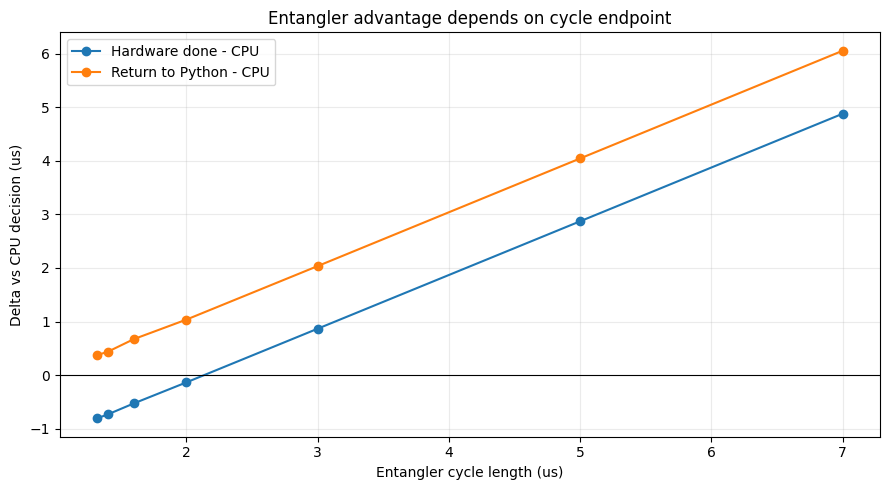

In [15]:
cycle_us = np.array([row["cycle_us"] for row in sweep])
done_after_click_us = np.array([row["done_after_click_mu"] for row in sweep]) * MU_TO_US
done_minus_cpu_us = np.array([row["done_minus_cpu_mu"] for row in sweep]) * MU_TO_US
return_minus_cpu_us = np.array([row["return_minus_cpu_mu"] for row in sweep]) * MU_TO_US

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cycle_us, done_minus_cpu_us, marker="o", label="Hardware done - CPU")
ax.plot(cycle_us, return_minus_cpu_us, marker="o", label="Return to Python - CPU")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Entangler cycle length (us)")
ax.set_ylabel("Delta vs CPU decision (us)")
ax.set_title("Entangler advantage depends on cycle endpoint")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Interpretation For The Current Experiment Workflow

The current experiment uses the actual SPCM timestamp to schedule later work:

```text
SPCM click time -> microwave mapping at click_time + offset
```

The follow-up branch also includes DDS updates, TTL switching, FORT ramping, blow-away, atom parity readout, and dataset updates. The current entangler core does not move that entire branch into hardware.

Therefore, replacing the current CPU timestamp branch with the current entangler core is not expected to make the Python-visible response faster. The entangler becomes useful for speed only if the time-critical response is implemented in gateware, for example:

```text
SPCM0-only match -> emit hardware response TTL
SPCM1-only match -> emit different hardware response TTL
pattern match -> start a gateware response sequencer
```

Without that gateware response path, the CPU branch remains the better fit for this local no-master/satellite workflow.